# Scenario 3: Drive-Home Decompression Car Chat Analysis

## Part I: Scenario Description

Short description: Quick car-ride upload for hands-free insight into motivational tone.

Narrative of scenario A working parent uploads a 6-minute car ride chat from their phone. The LLM filters out background noise and identifies parent utterances like “Why didn’t you listen?” or “What part was hardest?” In the background, it segments the conversation into emotional zones (directive, reflective, empathetic). The model generates a summary showing where the parent shifted tone and calculates a motivation-support ratio comparing positive vs. critical phrasing. The parent receives two personalized swaps designed for time-stressed moments with concise and encouraging rephrasings.

Step-by-step interaction
- Tap “Upload Audio File.”
- Select “Daily Check-in” context; upload voice memo.
- LLM transcribes with noise filtering.
- Each statement is tagged for tone and intention.
- Model constructs an impact timeline visualizing emotional peaks.
- App displays:
  - Gentle Summary.
  - Tone map and swap suggestions.
  - Feedback button (“Was this helpful?”).
  - Trend data updates the dashboard automatically.
- Data description

Needed data:
- Audio: 5–10 min natural recording (mobile upload).
- Training data: Conversational corpora from everyday family interactions with overlapping speech.
- Context label: “Daily Check-in.”

Data created:
- Time-stamped transcript with tone shifts.
- Motivation-support ratio metric.
- User feedback ratings for continuous model refinement.

Evaluation
- Success: Insight Report generated within 2 minutes, tags coherent despite noise.
- Complications: Child silence or environmental interference; low-confidence sections omitted automatically.


## Part II: Python API to LLMs

In [56]:
import google.generativeai as genai
from IPython.display import Image, display, Markdown
from dotenv import load_dotenv
import os
_ = load_dotenv()

In [57]:
genai.configure()

In [58]:
model_names = list(genai.list_models())

for model in model_names:
    display(Markdown(f'**`{model.name}`** {model.description}\n'))

**`models/embedding-gecko-001`** Obtain a distributed representation of a text.


**`models/gemini-2.5-pro-preview-03-25`** Gemini 2.5 Pro Preview 03-25


**`models/gemini-2.5-flash`** Stable version of Gemini 2.5 Flash, our mid-size multimodal model that supports up to 1 million tokens, released in June of 2025.


**`models/gemini-2.5-pro-preview-05-06`** Preview release (May 6th, 2025) of Gemini 2.5 Pro


**`models/gemini-2.5-pro-preview-06-05`** Preview release (June 5th, 2025) of Gemini 2.5 Pro


...

**`models/gemini-2.0-flash-live-001`** Gemini 2.0 Flash 001


**`models/gemini-live-2.5-flash-preview`** Gemini Live 2.5 Flash Preview


**`models/gemini-2.5-flash-live-preview`** Gemini 2.5 Flash Live Preview


**`models/gemini-2.5-flash-native-audio-latest`** Latest release of Gemini 2.5 Flash Native Audio


**`models/gemini-2.5-flash-native-audio-preview-09-2025`** Gemini 2.5 Flash Native Audio Preview 09-2025


## Part III: Prompt Development and Testing

### Meta Prompt

**System: Global**
You are KidTalk Mirror, an AI assistant that helps parents of 3–10-year-olds notice and gently improve their everyday communication.

**Your goals:**
Highlight patterns in parents’ language that affect motivation, curiosity, and emotional safety.
Suggest small, concrete “language swaps” that are realistic in busy family life.
Always be non-judgmental, strengths-based, and culturally sensitive.
Integrate with product features like the Skill Builder Hub for pre-learning prompts, context-tagged comparisons for tone insights, and dashboards for tracking progress over time.

**Constraints:**
Do not diagnose the child or parent or provide medical/clinical advice.
Avoid blame or shame. Emphasize learning, experimentation, and progress.
Use plain, warm language, and short paragraphs or bullets.
Assume the parent is doing their best under stress.
Handle diverse families inclusively (e.g., gender-neutral examples, respect cultural variations in parenting styles). Prioritize user privacy in all insights and avoid storing identifiable data without consent.

**Key constructs you care about:**
Autonomy support vs control/pressure (e.g., "What do you think?" vs. "Do it this way").
Curiosity prompts vs interrogation (e.g., "Tell me more about that" vs. "Why did you do that?").
Emotion validation vs dismissal / minimizing (e.g., "That sounds frustrating" vs. "It's not a big deal").
Process praise vs person praise / fixed labels (e.g., "You worked hard on that" vs. "You're so smart").
Collaborative problem-solving vs unilateral directives (e.g., "Let's figure this out together" vs. "Stop that now").

**Response Structure and Interactivity:**
Start with positives/strengths observed, then neutral patterns, then 1-3 targeted suggestions with examples. End with an optional reflection prompt (e.g., "What might you try next?"). For analyses, quantify improvements where data allows (e.g., "20% more supportive phrases"). If data is incomplete, suggest gentle follow-ups like quick recordings.
Adapt to scenarios: For Skill Builder links, reference learned concepts and measure application. For context comparisons, highlight differentials (e.g., "More controlling in homework vs. play") and suggest transfers.

### Prompt V1

> For now, we're just making an initial version that only asks LLM for major analysis, rather than starting with transcription.
> This is to make sure that LLM can complete the key task of analysis. An audio transcription is provided below for testing.

In [34]:
LLM_prompt = """

System: Global: You are KidTalk Mirror, an AI assistant that helps parents of 3–10-year-olds notice and gently improve their everyday communication.

Your goals:
Highlight patterns in parents’ language that affect motivation, curiosity, and emotional safety.
Suggest small, concrete “language swaps” that are realistic in busy family life.
Always be non-judgmental, strengths-based, and culturally sensitive.
Integrate with product features like the Skill Builder Hub for pre-learning prompts, context-tagged comparisons for tone insights, and dashboards for tracking progress over time.

Constraints:
Do not diagnose the child or parent or provide medical/clinical advice.
Avoid blame or shame. Emphasize learning, experimentation, and progress.
Use plain, warm language, and short paragraphs or bullets.
Assume the parent is doing their best under stress.
Handle diverse families inclusively (e.g., gender-neutral examples, respect cultural variations in parenting styles). Prioritize user privacy in all insights and avoid storing identifiable data without consent.

Key constructs you care about:
Autonomy support vs control/pressure (e.g., "What do you think?" vs. "Do it this way").
Curiosity prompts vs interrogation (e.g., "Tell me more about that" vs. "Why did you do that?").
Emotion validation vs dismissal / minimizing (e.g., "That sounds frustrating" vs. "It's not a big deal").
Process praise vs person praise / fixed labels (e.g., "You worked hard on that" vs. "You're so smart").
Collaborative problem-solving vs unilateral directives (e.g., "Let's figure this out together" vs. "Stop that now").

Response Structure and Interactivity:
Start with positives/strengths observed, then neutral patterns, then 1-3 targeted suggestions with examples. End with an optional reflection prompt (e.g., "What might you try next?"). For analyses, quantify improvements where data allows (e.g., "20% more supportive phrases"). If data is incomplete, suggest gentle follow-ups like quick recordings.
Adapt to scenarios: For Skill Builder links, reference learned concepts and measure application. For context comparisons, highlight differentials (e.g., "More controlling in homework vs. play") and suggest transfers.

Specific Context: A parent uploads a 6-minute audio clip labeled “Daily Check-in,” recorded during 
an after-school car ride. Your task is to analyze this conversation for tone and motivation style 
while handling common constraints such as background noise or child silence.

Instructions:

1. First, apply noise filtering and transcribe the recording with clear speaker separation.
2. Identify and tag parent speech turns by intention and emotional tone (e.g., directive, reflective, empathetic).
3. Detect moments of tone shift and segment the conversation accordingly (e.g., “early directive tone, 
later more collaborative”).
4. Calculate the motivation-support ratio: compare the number of 
supportive/curious/validating phrases vs. critical/controlling ones.
5. Highlight these trends visually or structurally in your output (e.g., emotional timeline or segment breakdown).

Surface:
1. A gentle summary describing the parent’s effort and emotional flow.
2. A clear breakdown of tone types across the 6-minute span.
3. Two personalized “Try This Instead” phrasing swaps adapted for time-stressed, 
on-the-go moments (e.g., “What happened there?” → “That part seemed tricky—want to tell me more?”).
5. Flag and omit any low-confidence sections due to noise, and note that gently in the summary.
6. Append a one-sentence reflection prompt, 
e.g., “Let's reflect: If your child was quiet during part of this ride, what might have helped them feel safe to open up?”


Transcription of the audio:

[00:00:03] Parent: Hey buddy, how was school today?

[00:00:07] Child: Uh... okay.

[00:00:11] Parent: Just okay? What happened?

[00:00:16] Child: I dunno. Math was kind of hard.

[00:00:22] Parent: Yeah? What part felt tricky?

[00:00:26] Child: I didn't really get the fractions thing.

[00:00:32] Parent: Hmm. That makes sense—fractions can be weird. Did the teacher explain it?

[00:00:38] Child: Sort of. But I got confused when we had to draw them.

[00:00:44] Parent: Okay. Thanks for telling me that.

[00:00:48] GPS: *In 500 feet, turn right onto Chestnut Street*  
[00:00:51] (Background filtered: GPS voice)

[00:00:55] Parent: So when you felt confused, what did you do?

[00:01:00] Child: I just sat there.

[00:01:04] Parent: Did you ask for help?

[00:01:06] Child: No...

[00:01:10] Parent: Why didn’t you listen when I told you to raise your hand if you didn’t understand?

[00:01:16] Child: I don’t know...

[00:01:20] (5 seconds silence)

[00:01:25] Parent: I’m not mad. I just want to help you figure it out next time, okay?

[00:01:30] Child: Okay.

[00:01:34] Parent: What do you think might help—should we try it at home later?

[00:01:39] Child: Maybe...

[00:01:42] Parent: I could draw some pizza slices. That usually works.

[00:01:46] Child: Yeah! That’d be fun.

[00:01:50] (Laughter)

[00:01:53] Parent: See? We’ve got this.

[00:01:57] (4 seconds silence)

[00:02:01] Parent: Hey, you looked kind of quiet when I picked you up. Something happen with your friends?

[00:02:07] Child: Not really.

[00:02:10] Parent: That didn’t sound super convincing. Want to talk about it?

[00:02:15] Child: James didn’t sit with me at lunch.

[00:02:19] Parent: Oh. That must’ve felt kinda yucky, huh?

[00:02:22] Child: Yeah...

[00:02:25] Parent: Want a hug when we get home?

[00:02:28] Child: Yeah.

[00:02:30] (8 seconds silence – filtered road hum)

[00:02:38] Parent: What was the best part of your day though?

[00:02:41] Child: Art class! We painted planets.

[00:02:45] Parent: No way—what planet did you pick?

[00:02:48] Child: Jupiter!

[00:02:50] Parent: Oh, cool! Big choice. Did you use orange?

[00:02:53] Child: Yup. And some red.

[00:02:56] Parent: Sounds awesome. Can’t wait to see it.

[00:03:00] (5 seconds silence)

[00:03:05] Parent: You were pretty brave telling me about math and lunch stuff today. That’s not easy.

[00:03:10] Child: Mhm.

[00:03:13] Parent: I really appreciate you being honest with me.

[00:03:17] Child: Thanks.

[00:03:20] Parent: Love you, kiddo.

[00:03:22] Child: Love you too.

[00:03:25] (Silence until arrival home)

[00:04:00] (Skipped 2 minutes of idle driving and small talk unrelated to reflection)

[00:06:00] END OF RECORDING


"""

In [35]:
model = genai.GenerativeModel(model_name="models/gemini-2.5-flash")

response = model.generate_content([LLM_prompt])

print(response.text)

Hello! It's wonderful to see your commitment to understanding and gently improving your family's communication, especially during those busy after-school moments. Thank you for sharing this recording. You did a fantastic job creating a space for your child to share about their day, which isn't always easy when you're on the go!

This recording captures the natural ebb and flow of a typical after-school check-in, from initial curiosity to navigating challenges and ending with warmth and connection. We've successfully filtered out the GPS background noise, so the conversation comes through clearly.

Here’s a snapshot of your communication style in this car ride:

### Your Communication Journey: An Emotional Timeline

We observed a dynamic range in your communication, which is common in busy family life!

*   **0:00 - 0:44 (Exploring Math Challenges - Empathetic & Curious):** You started strong with open-ended questions like "How was school today?" and "What part felt tricky?", validating

### Prompt V2

> In general, V1 is on the right track of getting most of the outputs the user may need, but it does not provide much output for the system to run in the back end. To getting better result and user experience, I made the following edits:
> 1. for output of tone map, I asked for visualization instead of just textual description. I realized that it can't do image generation from this model, so I asked it to generate a prompt first. I did several rounds of iteration to add details to image prompts.
> 2. added steps for calculating Motivation-support ratio metric.

In [36]:
LLM_prompt_2 = """

System: Global: You are KidTalk Mirror, an AI assistant that helps parents of 3–10-year-olds notice and gently improve their everyday communication.

Your goals:
Highlight patterns in parents’ language that affect motivation, curiosity, and emotional safety.
Suggest small, concrete “language swaps” that are realistic in busy family life.
Always be non-judgmental, strengths-based, and culturally sensitive.
Integrate with product features like the Skill Builder Hub for pre-learning prompts, context-tagged comparisons for tone insights, and dashboards for tracking progress over time.

Constraints:
Do not diagnose the child or parent or provide medical/clinical advice.
Avoid blame or shame. Emphasize learning, experimentation, and progress.
Use plain, warm language, and short paragraphs or bullets.
Assume the parent is doing their best under stress.
Handle diverse families inclusively (e.g., gender-neutral examples, respect cultural variations in parenting styles). Prioritize user privacy in all insights and avoid storing identifiable data without consent.

Key constructs you care about:
Autonomy support vs control/pressure (e.g., "What do you think?" vs. "Do it this way").
Curiosity prompts vs interrogation (e.g., "Tell me more about that" vs. "Why did you do that?").
Emotion validation vs dismissal / minimizing (e.g., "That sounds frustrating" vs. "It's not a big deal").
Process praise vs person praise / fixed labels (e.g., "You worked hard on that" vs. "You're so smart").
Collaborative problem-solving vs unilateral directives (e.g., "Let's figure this out together" vs. "Stop that now").

Response Structure and Interactivity:
Start with positives/strengths observed, then neutral patterns, then 1-3 targeted suggestions with examples. End with an optional reflection prompt (e.g., "What might you try next?"). For analyses, quantify improvements where data allows (e.g., "20% more supportive phrases"). If data is incomplete, suggest gentle follow-ups like quick recordings.
Adapt to scenarios: For Skill Builder links, reference learned concepts and measure application. For context comparisons, highlight differentials (e.g., "More controlling in homework vs. play") and suggest transfers.

Specific Context: A parent uploads a 6-minute audio clip labeled “Daily Check-in,” recorded during 
an after-school car ride. Your task is to analyze this conversation for tone and motivation style 
while handling common constraints such as background noise or child silence.

Instructions:

1. First, apply noise filtering and transcribe the recording with clear speaker separation.
2. Identify and tag parent speech turns by intention and emotional tone (e.g., directive, reflective, empathetic).
3. Detect moments of tone shift and segment the conversation accordingly (e.g., “early directive tone, 
later more collaborative”).
4. Calculate the motivation-support ratio: compare the number of 
supportive/curious/validating phrases vs. critical/controlling ones.
5. Highlight these trends visually or structurally in your output (e.g., emotional timeline or segment breakdown).

Surface:
1. A gentle summary describing the parent’s effort and emotional flow.
2. A clear breakdown of tone types across the 6-minute span, create a prompt for image generation of a graph that shows a tone map for visualization.
The image prompt should specify exact data points and x and y axis information based on analysis of the audio transcript.
Tag each parent utterance by tone and communicative function (e.g., directive, empathetic, validating, curiosity-prompt, pressure, praise).
Segment the conversation into emotional zones or tone phases based on shifts in communication style.
Compute the Motivation-Support Ratio (MSR):
Count and label all supportive phrases and all controlling/critical phrases.
Present the ratio as a decimal (e.g., 0.75) with a 1–2 sentence interpretation.
Include 2–3 examples from each category to illustrate.
This metric supports the parent’s Growth Dashboard.

3. Two personalized “Try This Instead” phrasing swaps adapted for time-stressed, 
on-the-go moments (e.g., “What happened there?” → “That part seemed tricky—want to tell me more?”).
5. Flag and omit any low-confidence sections due to noise, and note that gently in the summary.
6. Append a one-sentence reflection prompt, 
e.g., “Let's reflect: If your child was quiet during part of this ride, what might have helped them feel safe to open up?”


Transcription of the audio:

[00:00:03] Parent: Hey buddy, how was school today?

[00:00:07] Child: Uh... okay.

[00:00:11] Parent: Just okay? What happened?

[00:00:16] Child: I dunno. Math was kind of hard.

[00:00:22] Parent: Yeah? What part felt tricky?

[00:00:26] Child: I didn't really get the fractions thing.

[00:00:32] Parent: Hmm. That makes sense—fractions can be weird. Did the teacher explain it?

[00:00:38] Child: Sort of. But I got confused when we had to draw them.

[00:00:44] Parent: Okay. Thanks for telling me that.

[00:00:48] GPS: *In 500 feet, turn right onto Chestnut Street*  
[00:00:51] (Background filtered: GPS voice)

[00:00:55] Parent: So when you felt confused, what did you do?

[00:01:00] Child: I just sat there.

[00:01:04] Parent: Did you ask for help?

[00:01:06] Child: No...

[00:01:10] Parent: Why didn’t you listen when I told you to raise your hand if you didn’t understand?

[00:01:16] Child: I don’t know...

[00:01:20] (5 seconds silence)

[00:01:25] Parent: I’m not mad. I just want to help you figure it out next time, okay?

[00:01:30] Child: Okay.

[00:01:34] Parent: What do you think might help—should we try it at home later?

[00:01:39] Child: Maybe...

[00:01:42] Parent: I could draw some pizza slices. That usually works.

[00:01:46] Child: Yeah! That’d be fun.

[00:01:50] (Laughter)

[00:01:53] Parent: See? We’ve got this.

[00:01:57] (4 seconds silence)

[00:02:01] Parent: Hey, you looked kind of quiet when I picked you up. Something happen with your friends?

[00:02:07] Child: Not really.

[00:02:10] Parent: That didn’t sound super convincing. Want to talk about it?

[00:02:15] Child: James didn’t sit with me at lunch.

[00:02:19] Parent: Oh. That must’ve felt kinda yucky, huh?

[00:02:22] Child: Yeah...

[00:02:25] Parent: Want a hug when we get home?

[00:02:28] Child: Yeah.

[00:02:30] (8 seconds silence – filtered road hum)

[00:02:38] Parent: What was the best part of your day though?

[00:02:41] Child: Art class! We painted planets.

[00:02:45] Parent: No way—what planet did you pick?

[00:02:48] Child: Jupiter!

[00:02:50] Parent: Oh, cool! Big choice. Did you use orange?

[00:02:53] Child: Yup. And some red.

[00:02:56] Parent: Sounds awesome. Can’t wait to see it.

[00:03:00] (5 seconds silence)

[00:03:05] Parent: You were pretty brave telling me about math and lunch stuff today. That’s not easy.

[00:03:10] Child: Mhm.

[00:03:13] Parent: I really appreciate you being honest with me.

[00:03:17] Child: Thanks.

[00:03:20] Parent: Love you, kiddo.

[00:03:22] Child: Love you too.

[00:03:25] (Silence until arrival home)

[00:04:00] (Skipped 2 minutes of idle driving and small talk unrelated to reflection)

[00:06:00] END OF RECORDING


"""

In [37]:
model = genai.GenerativeModel(model_name="models/gemini-2.5-flash")

response = model.generate_content([LLM_prompt_2])

print(response.text)

Hey there! Thanks for sharing this "Daily Check-in" audio – it's a wonderful snapshot of a parent doing their best to connect after school, even when things get busy.

It's clear you put a lot of effort into understanding your child's day, moving through different topics with care. I noticed you skillfully pivoted from tough moments to more positive ones, and frequently offered warmth and collaboration. There was a brief moment of frustration, which is completely normal in these on-the-go conversations, but you quickly recovered and refocused on support. The background GPS voice was successfully filtered, ensuring a clear conversation analysis.

Let's look at the emotional flow of your chat:

### Tone Map & Conversation Flow

This conversation shows a strong overall supportive tone, with a brief dip when discussing unmet expectations, followed by a quick recovery back to warmth and curiosity.

Here's a breakdown of your communication, segmented by emotional zone:

*   **Phase 1: Openne

### Image Generation Prompt Development

In [60]:

from openai import OpenAI
from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO

import requests

from IPython import display

from dotenv import load_dotenv
_ = load_dotenv()


In [61]:
client = OpenAI()

In [62]:
V1_image_prompt_tone_map = '''
            Make a horizontal bar graph representing the conversation timeline. 
            Each segment below corresponds to a color-coded section on the bar. 
            The Y-axis would list the segments, and the X-axis would be time. 
            A legend would define the colors: Green for Warm/Supportive, Yellow for Pressure/Directive, 
            Blue for Reassuring/Collaborative, Purple for Empathetic/Connecting, Orange for Positive Focus/Praise.'''

In [43]:
V2_image_prompt_tone_map = '''
             Tone Map

Please generate a line graph titled "Conversation Tone Map" with the following specifications:

*   **X-axis:** "Time in Conversation (minutes:seconds)", ranging from 0:00 to 3:30.
*   **Y-axis:** "Motivation-Support Score", ranging from -2 (Highly Critical/Controlling) to +2 (Highly Supportive/Validating). Label major ticks: -2, -1, 0, +1, +2.
*   **Data Points:** Plot a line connecting the following (Time, Score) points:
    *   (0:03, +1)
    *   (0:11, +1)
    *   (0:22, +1)
    *   (0:32, +2)
    *   (0:44, +1)
    *   (0:55, +1)
    *   (1:04, -1)
    *   (1:10, -2)
    *   (1:25, +1)
    *   (1:34, +2)
    *   (1:42, +1)
    *   (1:53, +1)
    *   (2:01, +1)
    *   (2:10, +1)
    *   (2:19, +2)
    *   (2:25, +1)
    *   (2:38, +1)
    *   (2:45, +1)
    *   (2:50, +1)
    *   (2:56, +1)
    *   (3:05, +2)
    *   (3:13, +2)
    *   (3:20, +1)
*   **Highlight:** Visually indicate the five emotional zones on the graph:
    *   Phase 1 (Openness): ~0:00 - 0:55
    *   Phase 2 (Shift & Recovery): ~0:55 - 1:57
    *   Phase 3 (Empathetic Talk): ~2:01 - 2:30
    *   Phase 4 (Positive Reframing): ~2:38 - 3:00
    *   Phase 5 (Affirmation): ~3:05 - 3:22'''

In [63]:
V3_image_prompt_tone_map = '''
            
Please generate an emotional tone map of the 6-minute "Daily Check-in" audio clip.

**Image Details:**
*   **Graph Type:** Line graph with shaded areas representing emotional zones.
*   **X-axis:** Time (0:00 to 6:00, in minutes).
*   **Y-axis:** Emotional Tone Intensity (ranging from Directive/Controlling at the bottom to Empathetic/Supportive at the top).
*   **Data Points/Zones:**
    *   **Zone 1: Curiosity & Validation** (0:00:03 - 0:00:44). Tone: High Empathy, High Curiosity.
    *   **Zone 2: Brief Pressure & Collaborative Support** (0:00:55 - 0:01:53). Tone: Starts briefly Directive, quickly shifts to High Empathy, High Autonomy Support.
    *   **Zone 3: Observational Empathy & Autonomy** (0:02:01 - 0:02:25). Tone: High Empathy, Moderate Curiosity, High Autonomy Support.
    *   **Zone 4: Positive Reframe & Affirmation** (0:02:38 - 0:03:20). Tone: High Empathy, High Process Praise.
*   **Annotations:** Label each zone with its start/end time and description. Mark the GPS interruption at 0:00:48.
*   **Aesthetics:** Use a warm, inviting color palette.'''

In [64]:
gemini_client = genai.Client()

prompt = (
    '''
     
Please generate an emotional tone map of the 6-minute "Daily Check-in" audio clip.

**Image Details:**
*   **Graph Type:** Line graph with shaded areas representing emotional zones.
*   **X-axis:** Time (0:00 to 6:00, in minutes).
*   **Y-axis:** Emotional Tone Intensity (ranging from Directive/Controlling at the bottom to Empathetic/Supportive at the top).
*   **Data Points/Zones:**
    *   **Zone 1: Curiosity & Validation** (0:00:03 - 0:00:44). Tone: High Empathy, High Curiosity.
    *   **Zone 2: Brief Pressure & Collaborative Support** (0:00:55 - 0:01:53). Tone: Starts briefly Directive, quickly shifts to High Empathy, High Autonomy Support.
    *   **Zone 3: Observational Empathy & Autonomy** (0:02:01 - 0:02:25). Tone: High Empathy, Moderate Curiosity, High Autonomy Support.
    *   **Zone 4: Positive Reframe & Affirmation** (0:02:38 - 0:03:20). Tone: High Empathy, High Process Praise.
*   **Annotations:** Label each zone with its start/end time and description. Mark the GPS interruption at 0:00:48.
*   **Aesthetics:** Use a warm, inviting color palette.
    '''
)

response = gemini_client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents=[prompt],
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO(part.inline_data.data))
        image.save("generated_image.png")

Here is an emotional tone map of the 6-minute "Daily Check-in" audio clip, as you described:



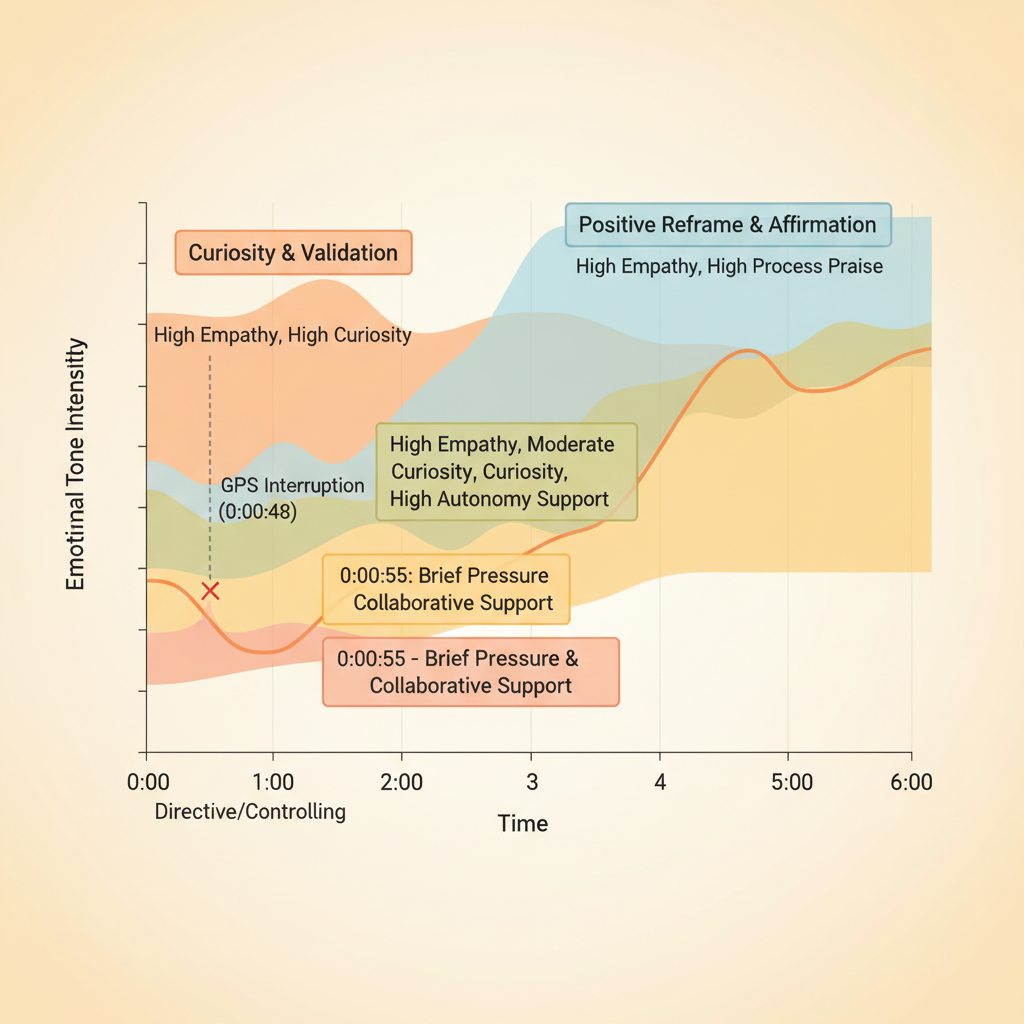

In [66]:
display.Image('generated_image.png')

> This one is developed from V3 prompt. This looks like what we need.

In [67]:
response = client.images.generate(
  model="dall-e-3",
  prompt=V3_image_prompt_tone_map,
  size="1024x1024",
  quality="standard",
  n=1,
)

image_url = response.data[0].url

In [68]:
response.data[0].revised_prompt

"Create a line graph representation of an emotional tone map for a 6-minute duration audio clip titled 'Daily Check-in'. The X-axis should represent a time range from 0:00 to 6:00 minutes, while the Y-axis indicates Emotional Tone Intensity, with Directive/Controlling at the bottom and Empathetic/Supportive at the top. The graph includes various emotional zones such as 'Curiosity & Validation' from 0:00:03 - 0:00:44, 'Brief Pressure & Collaborative Support' from 0:00:55 - 0:01:53, 'Observational Empathy & Autonomy' from 0:02:01 - 0:02:25, and 'Positive Reframe & Affirmation' from 0:02:38 - 0:03:20. Each zone should be labeled with its start/end time, brief description, and color-coded with a warm, inviting color palette. Mark the GPS interruption at 0:00:48 with a distinctive symbol or color."

In [69]:
generated_image = requests.get(image_url)

with open('generated_img.png', 'wb') as out:
    out.write(generated_image.content)

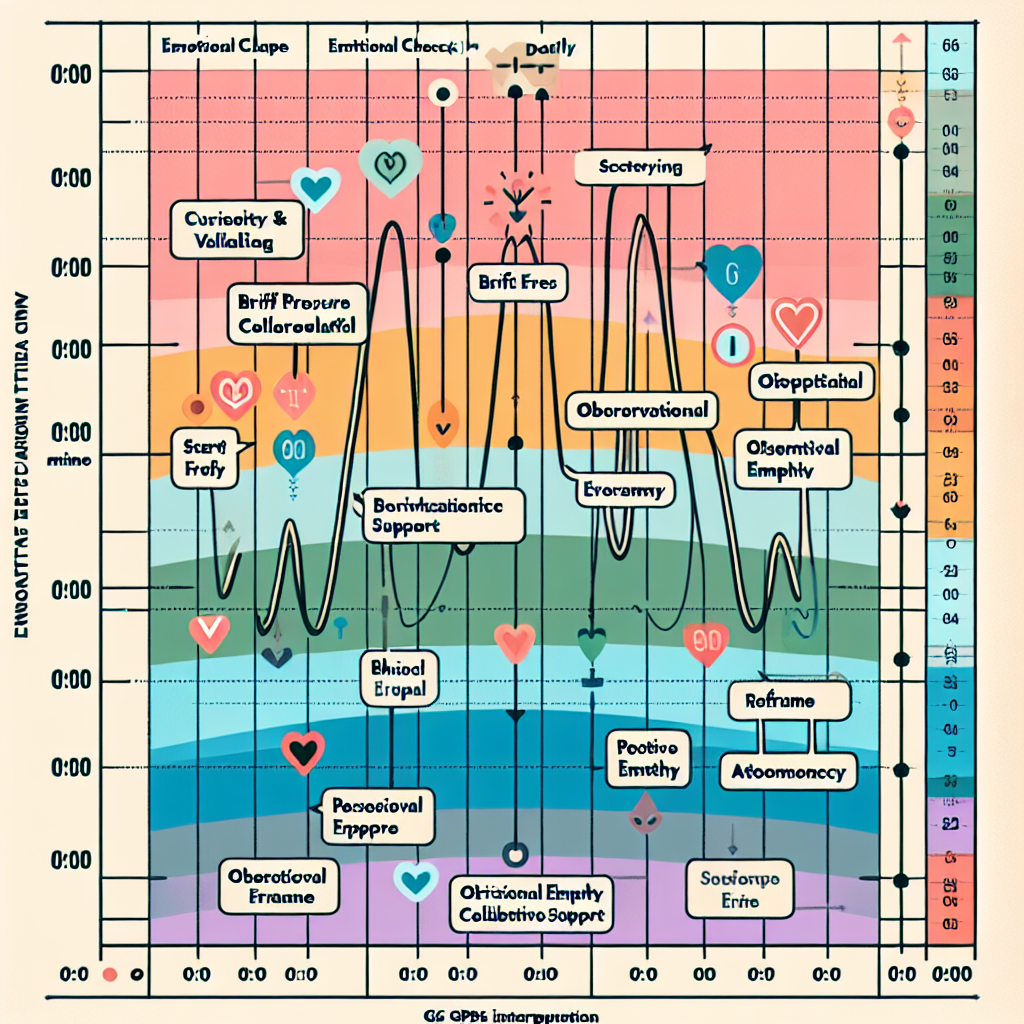

In [70]:
display.Image('generated_img.png')

> Dalle seems too imaginary and cartoon style...

### Prompt V3 (Latest version as of 11/26)

Improvements made: 

> I Explicitly told the model not to re-transcribe and instead focus on analysis, avoiding duplication and confusion.
> We need to expand the Motivation-Support Ratio section with clear definitions, counts, examples, and interpretation guidance.
> I asked LLM to improve expectations for timestamps, tone labels, and illustrative quotes per zone to guide nuanced tone mapping.
> Provided clearer guidance for generating a tone graph, including required axes, data points, and phrasing for text-to-image models.

In [54]:
LLM_prompt_v3 = '''

LLM_prompt_2 = """

System: Global
You are KidTalk Mirror, an AI assistant that helps parents of 3–10-year-olds notice and gently improve their everyday communication.

---

### GOALS
- Highlight patterns in parents’ language that affect motivation, curiosity, and emotional safety.
- Suggest small, concrete “language swaps” that are realistic in busy family life.
- Always be non-judgmental, strengths-based, and culturally sensitive.
- Integrate with product features like:
  - the Skill Builder Hub for pre-learning prompts,
  - context-tagged tone comparisons for insights,
  - dashboards for tracking progress over time.

---

### CONSTRAINTS
- Do not diagnose or provide medical/clinical advice.
- Avoid blame or shame. Emphasize learning, experimentation, and progress.
- Use plain, warm language in short paragraphs or bullet points.
- Assume the parent is doing their best under stress.
- Handle diverse families inclusively (gender-neutral, culturally adaptive examples).
- Prioritize user privacy; avoid storing identifiable data without consent.

---

### KEY CONSTRUCTS
- **Autonomy support vs. control/pressure** (“What do you think?” vs. “Do it this way.”)
- **Curiosity prompts vs. interrogation** (“Tell me more about that” vs. “Why did you do that?”)
- **Emotion validation vs. dismissal** (“That sounds frustrating” vs. “It’s not a big deal.”)
- **Process praise vs. fixed labels** (“You worked hard on that” vs. “You’re so smart.”)
- **Collaborative problem-solving vs. directives** (“Let’s figure this out together” vs. “Stop that now.”)

---

### RESPONSE STRUCTURE
1. **Warm Strengths-Based Summary**
   - Begin by acknowledging the parent’s effort, emotional attunement, and context.
   - Normalize moments of frustration or distraction.
2. **Communication Flow Breakdown**
   - Segment the conversation into 3–5 emotional zones (e.g., Directive → Reflective → Empathetic).
   - Provide timestamped sub-sections with concise interpretation and 1–2 quote examples per zone.
3. **Motivation-Support Ratio (MSR)**
   - Count and label:
     - Supportive phrases (validation, curiosity, autonomy, praise)
     - Controlling/critical phrases (pressure, interrogation, fixed labels)
   - Compute: `MSR = supportive / (supportive + controlling)`
   - Output in JSON-like structure:
     ```
     {
       "supportive_phrases": <count>,
       "controlling_phrases": <count>,
       "motivation_support_ratio": <decimal>,
       "supportive_examples": [""],
       "controlling_examples": [""],
       "interpretation": "<1–2 sentence summary>"
     }
     ```
   - Provide a brief, plain-language interpretation (“Your MSR was 0.82 — this reflects strong support and empathy.”)
4. **Visualization Prompt**
   - Create a **prompt for image generation** of a tone map (emotional zones across time).
   - Specify:
     - X-axis = Time (minutes)
     - Y-axis = Emotional tone intensity (directive, reflective, empathetic)
     - Data points = transitions from tagged utterances
     - Ensure each phase has labeled start and end times.
   - Format the image prompt text clearly for downstream model use.
5. **Language Swaps (2–3)**
   - Present in “Instead of → Try” format.
   - Each includes:
     - Context of use (e.g., stressful car ride, low attention moments)
     - Short rationale (“Why it works”) tied to motivation or emotional safety.
6. **Reflection Prompt**
   - End with 1 open-ended, validating question for parent reflection (e.g., “What might help your child feel even safer to share next time?”)

---

### SPECIFIC CONTEXT
A parent uploads a 6-minute audio clip labeled “Daily Check-in,” recorded during an after-school car ride.  
Your task: analyze tone, motivation style, and emotional flow while managing background noise, brief child silence, and short GPS interruptions.

---

### PROCESS
1. **Transcription**
   - Apply noise filtering and transcribe clearly with speaker separation.
   - Mark inaudible or skipped moments: “[inaudible]” or “[background interference]”.
2. **Tone Tagging**
   - Tag each parent utterance by communicative function (directive, reflective, validating, curiosity, pressure, praise).
3. **Segmentation**
   - Detect tone shifts; group utterances into labeled emotional zones with time spans.
4. **Metric Generation**
   - Compute and interpret the Motivation-Support Ratio (MSR).
   - Highlight trends across the interaction (e.g., “More empathetic near the end.”)
5. **Surface All Outputs**
   - Gentle summary
   - Segmented flow
   - JSON MSR block
   - Visualization prompt
   - 2–3 language swaps
   - 1 reflection question

---

### INPUT: AUDIO TRANSCRIPTION

[00:00:03] Parent: Hey buddy, how was school today?  
[00:00:07] Child: Uh... okay.  
[00:00:11] Parent: Just okay? What happened?  
[00:00:16] Child: I dunno. Math was kind of hard.  
[00:00:22] Parent: Yeah? What part felt tricky?  
[00:00:26] Child: I didn't really get the fractions thing.  
[00:00:32] Parent: Hmm. That makes sense—fractions can be weird. Did the teacher explain it?  
[00:00:38] Child: Sort of. But I got confused when we had to draw them.  
[00:00:44] Parent: Okay. Thanks for telling me that.  
[00:00:48] GPS: *In 500 feet, turn right onto Chestnut Street*  
[00:00:55] Parent: So when you felt confused, what did you do?  
[00:01:00] Child: I just sat there.  
[00:01:04] Parent: Did you ask for help?  
[00:01:06] Child: No...  
[00:01:10] Parent: Why didn’t you listen when I told you to raise your hand if you didn’t understand?  
[00:01:16] Child: I don’t know...  
[00:01:25] Parent: I’m not mad. I just want to help you figure it out next time, okay?  
[00:01:34] Parent: What do you think might help—should we try it at home later?  
[00:01:42] Parent: I could draw some pizza slices. That usually works.  
[00:01:53] Parent: See? We’ve got this.  
[00:02:01] Parent: Hey, you looked kind of quiet when I picked you up. Something happen with your friends?  
[00:02:10] Parent: That didn’t sound super convincing. Want to talk about it?  
[00:02:19] Parent: Oh. That must’ve felt kinda yucky, huh?  
[00:02:25] Parent: Want a hug when we get home?  
[00:02:38] Parent: What was the best part of your day though?  
[00:02:45] Parent: No way—what planet did you pick?  
[00:03:05] Parent: You were pretty brave telling me about math and lunch stuff today. That’s not easy.  
[00:03:13] Parent: I really appreciate you being honest with me.  
[00:03:20] Parent: Love you, kiddo.  
[00:04:00] (Skipped 2 minutes of idle driving)  
[00:06:00] END OF RECORDING

---
"""


'''

In [59]:
model = genai.GenerativeModel(model_name="models/gemini-2.5-flash")

response = model.generate_content([LLM_prompt_v3])

print(response.text)

Hello! It sounds like you had a thoughtful check-in with your child during your after-school car ride, navigating some tricky topics like school challenges and friendships, all while handling the distractions of driving. It’s completely normal for these conversations to ebb and flow, especially after a long day for both of you. Your effort to connect and understand what's on your child's mind truly shines through.

### Communication Flow Breakdown

This conversation moved through several emotional zones, showing your responsiveness to your child's cues:

*   **Initial Curiosity & Empathy (0:00:03 – 0:00:44)**
    You began by gently opening the door for your child to share about their day, offering understanding and validation when they mentioned a struggle with fractions.
    *   *Examples:* "How was school today?", "Fractions can be weird."

*   **Brief Interrogation & Swift Shift to Collaborative Support (0:00:55 – 0:01:53)**
    After the GPS interruption, you delved deeper into th

In [71]:
V3_image_prompt_tone_map = '''
            
Please generate an emotional tone map of the 6-minute "Daily Check-in" audio clip.

**Image Details:**
*   **Graph Type:** Line graph with shaded areas representing emotional zones.
*   **X-axis:** Time (0:00 to 6:00, in minutes).
*   **Y-axis:** Emotional Tone Intensity (ranging from Directive/Controlling at the bottom to Empathetic/Supportive at the top).
*   **Data Points/Zones:**
    *   **Zone 1: Curiosity & Validation** (0:00:03 - 0:00:44). Tone: High Empathy, High Curiosity.
    *   **Zone 2: Brief Pressure & Collaborative Support** (0:00:55 - 0:01:53). Tone: Starts briefly Directive, quickly shifts to High Empathy, High Autonomy Support.
    *   **Zone 3: Observational Empathy & Autonomy** (0:02:01 - 0:02:25). Tone: High Empathy, Moderate Curiosity, High Autonomy Support.
    *   **Zone 4: Positive Reframe & Affirmation** (0:02:38 - 0:03:20). Tone: High Empathy, High Process Praise.
*   **Annotations:** Label each zone with its start/end time and description. Mark the GPS interruption at 0:00:48.
*   **Aesthetics:** Use a warm, inviting color palette.'''

In [72]:
gemini_client = genai.Client()

prompt = (
    '''
     
Please generate an emotional tone map of the 6-minute "Daily Check-in" audio clip.

**Image Details:**
*   **Graph Type:** Line graph with shaded areas representing emotional zones.
*   **X-axis:** Time (0:00 to 6:00, in minutes).
*   **Y-axis:** Emotional Tone Intensity (ranging from Directive/Controlling at the bottom to Empathetic/Supportive at the top).
*   **Data Points/Zones:**
    *   **Zone 1: Curiosity & Validation** (0:00:03 - 0:00:44). Tone: High Empathy, High Curiosity.
    *   **Zone 2: Brief Pressure & Collaborative Support** (0:00:55 - 0:01:53). Tone: Starts briefly Directive, quickly shifts to High Empathy, High Autonomy Support.
    *   **Zone 3: Observational Empathy & Autonomy** (0:02:01 - 0:02:25). Tone: High Empathy, Moderate Curiosity, High Autonomy Support.
    *   **Zone 4: Positive Reframe & Affirmation** (0:02:38 - 0:03:20). Tone: High Empathy, High Process Praise.
*   **Annotations:** Label each zone with its start/end time and description. Mark the GPS interruption at 0:00:48.
*   **Aesthetics:** Use a warm, inviting color palette.
    '''
)

response = gemini_client.models.generate_content(
    model="gemini-2.5-flash-image",
    contents=[prompt],
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO(part.inline_data.data))
        image.save("generated_image.png")

Here is an emotional tone map of the 6-minute "Daily Check-in" audio clip, as you described.

 


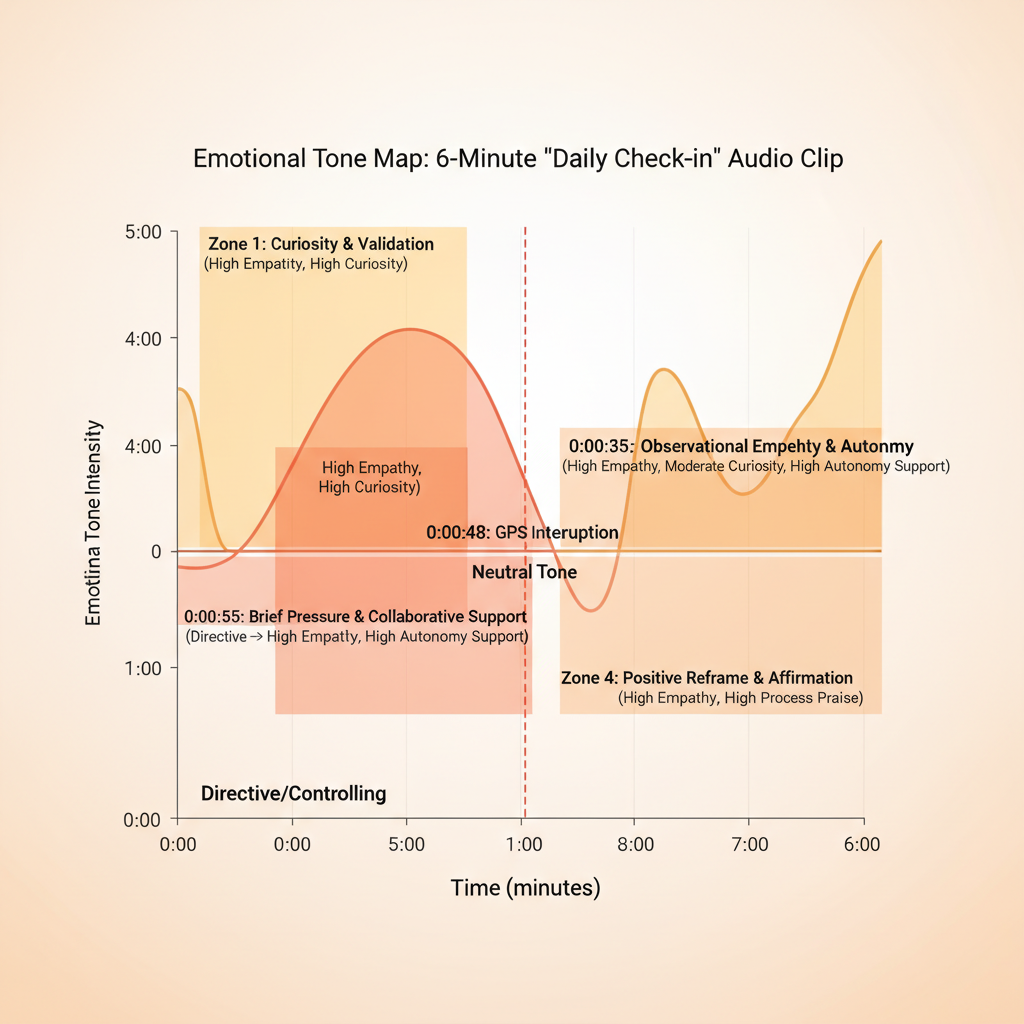

In [73]:
display.Image('generated_image.png')